In [35]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message=".*tight_layout.*")

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family":      "Arial",
    "font.size":        13,
    "axes.labelsize":   14,
    "axes.titlesize":   15,
    "axes.titleweight": "bold",
    "xtick.labelsize":  14,
    "ytick.labelsize":  12,
    "legend.fontsize":  11,
    "figure.dpi":       110,
    "savefig.dpi":      300,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

COLORS = {
    "cold":       "#1f4e79",   # deep blue
    "warm":       "#c0392b",   # warm red
    "melt":       "#2c7fb8",   # medium blue
    "gw":         "#1565c0",   # GW signature blue
    "gw_hatch":   "#5d6d7e",   # grey hatch
    "sw":         "#e74c3c",   # SW red marker
    "sw_hatch":   "#1b3a6b",   # navy hatch
    "ditch":      "#8e44ad",   # purple
    "anomaly":    "#000000",   # black (special zone)
    "baseline":   "#16a085",   # teal baseline
}

In [36]:
# ---------------------------------------------------------------------------
# File paths
# ---------------------------------------------------------------------------
DTS_FILE    = Path(r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\DTS\pallas_dts_data_f_6.nc")
RUNOFF_FILE = Path(r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\Forcing\30 min interval Discharge.New csv file.csv")
SNOW_FILE   = Path(r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\Forcing\Snow depth kittila.csv")
GW_CSV      = Path(r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\FINAL CSV FILES\GW_inflow_locations_slope.csv")  # resolved relative to the notebook

# ---------------------------------------------------------------------------
# Time-filter controls
# ---------------------------------------------------------------------------
TIME_PERIOD        = "night"   # "night" | "day" | "all"
APPLY_MELT_FILTER  = True      # require snow > SNOW_THRESH and Q > Q_THRESH
SNOW_THRESH        = 0.0       # m snow depth
Q_THRESH           = 0.2       # m^3/s

# ---------------------------------------------------------------------------
# GW-detection parameters  (from DTS GW & SW Classifications)
# ---------------------------------------------------------------------------
GW_WINDOW          = 40        # rolling-slope window (points)
GW_GRAD_THRESH     = 0.0015    # |dT/dx| threshold for reversal (°C/m)
GW_COHERENCE_WIN   = 10        # spatial-coherence window
GW_COHERENCE_MIN   = 6         # min. cells in coherence window
GW_SPRING_LO       = 4.0       # °C — both 25th and 75th quantile in this band
GW_SPRING_HI       = 5.0       # °C

# Special markers inside/around the ditch for the main GW figure
ANOMALY_RANGE      = (675.0, 763.0)
PURPLE_RANGE       = (620.0, 650.0)

# ---------------------------------------------------------------------------
# SW-detection parameters 
# ---------------------------------------------------------------------------
SW_WINDOW          = 40        # rolling-slope window
SW_D2_WINDOW       = 20        # 2nd-derivative window
SW_COOL_THRESH     = 0.03      # °C below upstream baseline
SW_GW_MASK_X       = 1800.0    # x above which GW-spring zone is masked from baseline
SW_COHERENCE_WIN   = 5
SW_COHERENCE_MIN   = 2
SW_UPSTREAM_LIMIT  = 1900.0    # drop detections above this x
SW_FWD_EXT         = 8         # forward extension (points)
SW_VICINITY_EXT    = 25        # vicinity extension into cooling pixels
SW_MERGE_TOL       = 15.0      # merge close segments (m)

print("User controls loaded.")
print(f"  Time period      : {TIME_PERIOD}")
print(f"  Melt filter      : {APPLY_MELT_FILTER}")
print(f"  GW grad thresh   : {GW_GRAD_THRESH} °C/m")
print(f"  SW cool thresh   : {SW_COOL_THRESH} °C")

User controls loaded.
  Time period      : night
  Melt filter      : True
  GW grad thresh   : 0.0015 °C/m
  SW cool thresh   : 0.03 °C


In [37]:
def merge_intervals(intervals, tol=0.0):
    """Merge overlapping / near-touching (s, e) intervals."""
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda t: t[0])
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + tol:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(a, b) for a, b in merged]


def extract_segments(xvals, mask01):
    """Convert a 0/1 mask along `xvals` into a list of (start, end) segments."""
    segments = []
    in_seg = False
    start = None
    for i in range(len(xvals)):
        if mask01[i] == 1 and not in_seg:
            start = xvals[i]
            in_seg = True
        if in_seg and (mask01[i] == 0 or i == len(xvals) - 1):
            end = xvals[i - 1] if mask01[i] == 0 else xvals[i]
            segments.append((start, end))
            in_seg = False
    return segments


def rolling_slope(T, window):
    """Centred rolling linear-regression slope of T(x)."""
    T_roll = T.rolling(x=window, center=True).construct("window")
    x_win  = T["x"].rolling(x=window, center=True).construct("window")
    x_cent = x_win - T["x"].values[:, None]
    num = (x_cent * T_roll).mean("window") - x_cent.mean("window") * T_roll.mean("window")
    den = (x_cent ** 2).mean("window") - (x_cent.mean("window")) ** 2
    return num / den


def upstream_baseline(da, window):
    """Flow direction is x = 2000 m -> 0 m, so 'upstream' = larger x.
    Build a trailing rolling mean in the upstream direction, excluding self."""
    s_rev    = pd.Series(da.values[::-1])
    base_rev = s_rev.shift(1).rolling(window=window, min_periods=5).mean()
    return xr.DataArray(base_rev.values[::-1], coords={"x": da["x"]}, dims="x")


def segments_from_mask(x_arr, mask, merge_tol=0.0):
    """Convenience wrapper."""
    return merge_intervals(extract_segments(x_arr, mask), tol=merge_tol)

In [38]:
data = xr.open_dataset(DTS_FILE)

# ---- Discharge --------------------------------------------------------------
runoff_df = pd.read_csv(RUNOFF_FILE)
runoff_df["time"] = pd.to_datetime(runoff_df["datetime"])
runoff_df = runoff_df.set_index("time").sort_index()
Q = pd.to_numeric(runoff_df["Discharge"], errors="coerce").dropna()
Q_xr = xr.DataArray(Q.values, coords={"time": Q.index}, dims="time")

# ---- Snow depth -------------------------------------------------------------
snow_df = pd.read_csv(SNOW_FILE, low_memory=False)
snow_df["time"] = pd.to_datetime(
    snow_df["Year"].astype(str) + "-"
    + snow_df["Month"].astype(str).str.zfill(2) + "-"
    + snow_df["Day"].astype(str).str.zfill(2) + " "
    + snow_df["Time [Local time]"].astype(str),
    errors="coerce",
)
snow_df = snow_df.dropna(subset=["time"]).set_index("time").sort_index()
_snow_col = "Snow depth [cm]"
snow_df[_snow_col] = pd.to_numeric(snow_df[_snow_col], errors="coerce")
snow_df.loc[snow_df[_snow_col] < 0, _snow_col] = 0.0
snow_df = snow_df.groupby(snow_df.index).mean(numeric_only=True)
snow_xr = xr.DataArray(
    (snow_df[_snow_col] / 100.0).values,  # cm -> m
    coords={"time": snow_df.index},
    dims="time",
)

# ---- Align onto DTS time ----------------------------------------------------
dts_time = data["time"]
Q_xr     = Q_xr.interp(time=dts_time)
snow_xr  = snow_xr.interp(time=dts_time)

print(f"DTS : {data.sizes['time']} timesteps × {data.sizes['x']} spatial cells")
print(f"  x  range : {float(data['x'].min()):.1f} – {float(data['x'].max()):.1f} m")
print(f"  time     : {str(dts_time.values[0])[:10]} → {str(dts_time.values[-1])[:10]}")

DTS : 57527 timesteps × 927 spatial cells
  x  range : 60.6 – 1939.6 m
  time     : 2021-06-15 → 2024-09-25


In [39]:
tp = TIME_PERIOD.lower().strip()
if tp == "night":
    period_mask  = (dts_time.dt.hour >= 22) | (dts_time.dt.hour < 6)
    period_label = "night (22:00–06:00)"
elif tp == "day":
    period_mask  = (dts_time.dt.hour >= 6) & (dts_time.dt.hour < 22)
    period_label = "day (06:00–22:00)"
elif tp == "all":
    period_mask  = xr.ones_like(dts_time, dtype=bool)
    period_label = "all hours"
else:
    raise ValueError("TIME_PERIOD must be 'night', 'day', or 'all'")

if APPLY_MELT_FILTER:
    melt_mask = period_mask & (snow_xr > SNOW_THRESH) & (Q_xr > Q_THRESH)
    filt_label = f"{period_label}  +  snow > {SNOW_THRESH} m,  Q > {Q_THRESH} m³/s"
else:
    melt_mask = period_mask
    filt_label = period_label

data_period = data.sel(time=period_mask)
data_melt   = data.sel(time=melt_mask)

# Seasonal-envelope profiles (inter-quartile range as "cold" / "warm" baselines)
min_data  = data_period["T"].quantile(0.25, dim="time").dropna(dim="x")
max_data  = data_period["T"].quantile(0.75, dim="time").dropna(dim="x")

# Melt-season mean profile
melt_mean = data_melt["T"].mean(dim="time").dropna(dim="x")
x         = melt_mean["x"]
x_vals    = x.values

print(f"Filter           : {filt_label}")
print(f"  envelope steps : {int(period_mask.sum()):>6}")
print(f"  melt steps     : {int(melt_mask.sum()):>6}")
print(f"  profile length : {len(x_vals)} cells  ({x_vals.min():.1f}–{x_vals.max():.1f} m)")

Filter           : night (22:00–06:00)  +  snow > 0.0 m,  Q > 0.2 m³/s
  envelope steps :  19179
  melt steps     :    732
  profile length : 651 cells  (70.7–1939.6 m)


In [40]:
# ---- Rolling slopes --------------------------------------------------------
min_deriv = rolling_slope(min_data,  GW_WINDOW)
max_deriv = rolling_slope(max_data,  GW_WINDOW)

# ---- Reversal + spatial coherence ------------------------------------------
gw_class = xr.where(
    (min_deriv < -GW_GRAD_THRESH) & (max_deriv > GW_GRAD_THRESH),
    1, np.nan,
)
gw_class = xr.where(
    gw_class.rolling(x=GW_COHERENCE_WIN, center=True, min_periods=1).sum() > GW_COHERENCE_MIN,
    1, np.nan,
)

# ---- Spring-temperature exception ------------------------------------------
spring_mask = (
    (min_data > GW_SPRING_LO) & (min_data < GW_SPRING_HI) &
    (max_data > GW_SPRING_LO) & (max_data < GW_SPRING_HI)
)
gw_class = xr.where(spring_mask, 1, gw_class)

gw_mask     = gw_class.fillna(0).values.astype(int)
gw_segments = segments_from_mask(x_vals, gw_mask)

# ---- Hatch zones: CSV reversal zones + ditch anomaly -----------------------
csv_df = pd.read_csv(GW_CSV)
csv_segments = [(float(a), float(b))
                for a, b in zip(csv_df["x_start_m"].values, csv_df["x_end_m"].values)]
csv_segments.append(ANOMALY_RANGE)
gw_hatch_segments = merge_intervals(csv_segments, tol=0.0)

anom_mask   = (x >= ANOMALY_RANGE[0]) & (x <= ANOMALY_RANGE[1])
purple_mask = (x >= PURPLE_RANGE[0])  & (x <= PURPLE_RANGE[1])

print(f"GW cells detected  : {int(gw_mask.sum())}  "
      f"({100 * gw_mask.mean():.1f}% of the line)")
print(f"GW hatch zones     : {len(gw_hatch_segments)}")
print(f"GW contiguous segs : {len(gw_segments)}")

GW cells detected  : 100  (15.4% of the line)
GW hatch zones     : 5
GW contiguous segs : 4


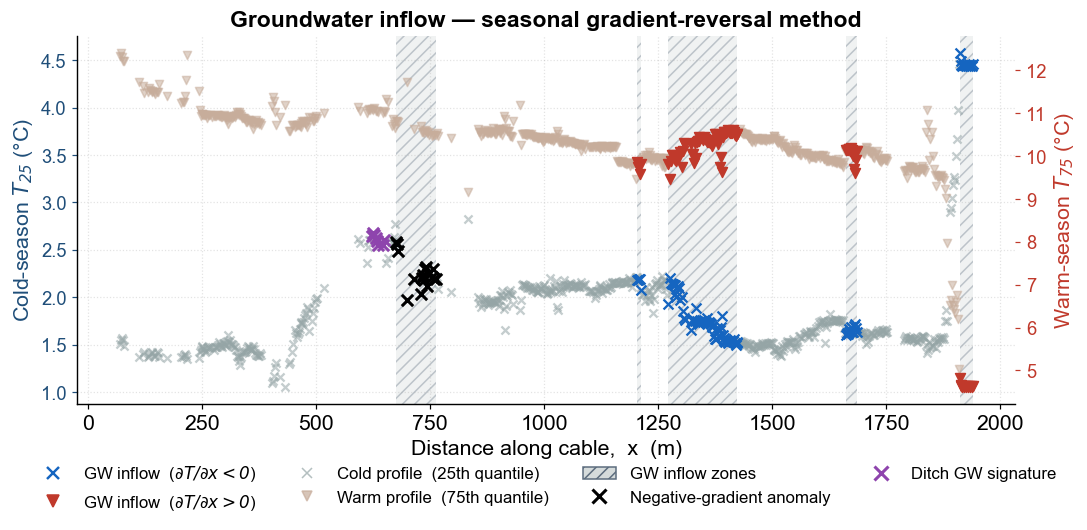

In [41]:
fig_gw = plt.figure(figsize=(11, 5.6))
gs_gw  = mpl.gridspec.GridSpec(2, 1, height_ratios=[5, 1], hspace=0.15)

ax_c   = fig_gw.add_subplot(gs_gw[0])       # cold (25th quantile)
ax_w   = ax_c.twinx()                       # warm (75th quantile)
ax_lg  = fig_gw.add_subplot(gs_gw[1])
ax_lg.axis("off")

# Shaded GW hatch zones
for xs_, xe_ in gw_hatch_segments:
    ax_c.axvspan(xs_, xe_, facecolor="#d5dbdb", edgecolor=COLORS["gw_hatch"],
                 hatch="///", alpha=0.35, linewidth=0.0, zorder=1)

# Classify the individual cold-profile markers
cold_is_black = anom_mask.values
cold_is_blue  = (gw_mask == 1) & (~cold_is_black)
cold_is_purp  = purple_mask.values
cold_is_bg    = (~cold_is_blue) & (~cold_is_black) & (~cold_is_purp)

ax_c.scatter(x[cold_is_bg],   min_data.values[cold_is_bg],
             color="#95a5a6", marker="x", s=28, alpha=0.55, zorder=2,
             label="Cold profile — background")
ax_c.scatter(x[cold_is_blue], min_data.values[cold_is_blue],
             color=COLORS["gw"], marker="x", s=42, linewidths=1.5, zorder=4,
             label=r"GW inflow ($\partial T / \partial x < 0$)")
ax_c.scatter(x[cold_is_black], min_data.values[cold_is_black],
             color=COLORS["anomaly"], marker="x", s=55, linewidths=2.0, zorder=5,
             label="Negative-gradient anomaly")
ax_c.scatter(x[cold_is_purp], min_data.values[cold_is_purp],
             color=COLORS["ditch"], marker="x", s=55, linewidths=2.0, zorder=5,
             label="Ditch GW signature")

# Warm profile on twin axis
warm_bg  = gw_mask != 1
ax_w.scatter(x[warm_bg],        max_data.values[warm_bg],
             color="#c7ad9b", marker="v", s=28, alpha=0.55, zorder=2,
             label="Warm profile — background")
ax_w.scatter(x[gw_mask == 1],   max_data.values[gw_mask == 1],
             color=COLORS["warm"], marker="v", s=42, zorder=4,
             label=r"GW inflow ($\partial T / \partial x > 0$)")

ax_c.set_ylabel("Cold-season $T_{25}$ (°C)", color=COLORS["cold"])
ax_w.set_ylabel("Warm-season $T_{75}$ (°C)", color=COLORS["warm"])
ax_c.tick_params(axis="y", colors=COLORS["cold"])
ax_w.tick_params(axis="y", colors=COLORS["warm"])
ax_c.set_xlabel("Distance along cable,  x  (m)")
ax_c.grid(True, linestyle=":", alpha=0.35)
ax_c.set_title("Groundwater inflow — seasonal gradient-reversal method")

legend_handles = [
    Line2D([], [], color=COLORS["gw"],     marker="x", linestyle="",
           markersize=8, markeredgewidth=1.6),
    Line2D([], [], color=COLORS["warm"],   marker="v", linestyle="",
           markersize=8),
    Line2D([], [], color="#95a5a6",        marker="x", linestyle="",
           markersize=7, alpha=0.7),
    Line2D([], [], color="#c7ad9b",        marker="v", linestyle="",
           markersize=7, alpha=0.7),
    mpatches.Patch(facecolor="#d5dbdb", edgecolor=COLORS["gw_hatch"], hatch="///"),
    Line2D([], [], color=COLORS["anomaly"], marker="x", linestyle="",
           markersize=9, markeredgewidth=2),
    Line2D([], [], color=COLORS["ditch"],   marker="x", linestyle="",
           markersize=9, markeredgewidth=2),
]
legend_labels = [
    r"GW inflow  ($\partial T / \partial x < 0$)",
    r"GW inflow  ($\partial T / \partial x > 0$)",
    "Cold profile  (25th quantile)",
    "Warm profile  (75th quantile)",
    "GW inflow zones",
    "Negative-gradient anomaly",
    "Ditch GW signature",
]
ax_lg.legend(legend_handles, legend_labels,
             loc="center", bbox_to_anchor=(0.5, 0.3),
             ncol=4, frameon=False)

plt.tight_layout()
plt.show()

Saved PNG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\GW.png
Saved PDF: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\GW.pdf
Saved SVG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\GW.svg


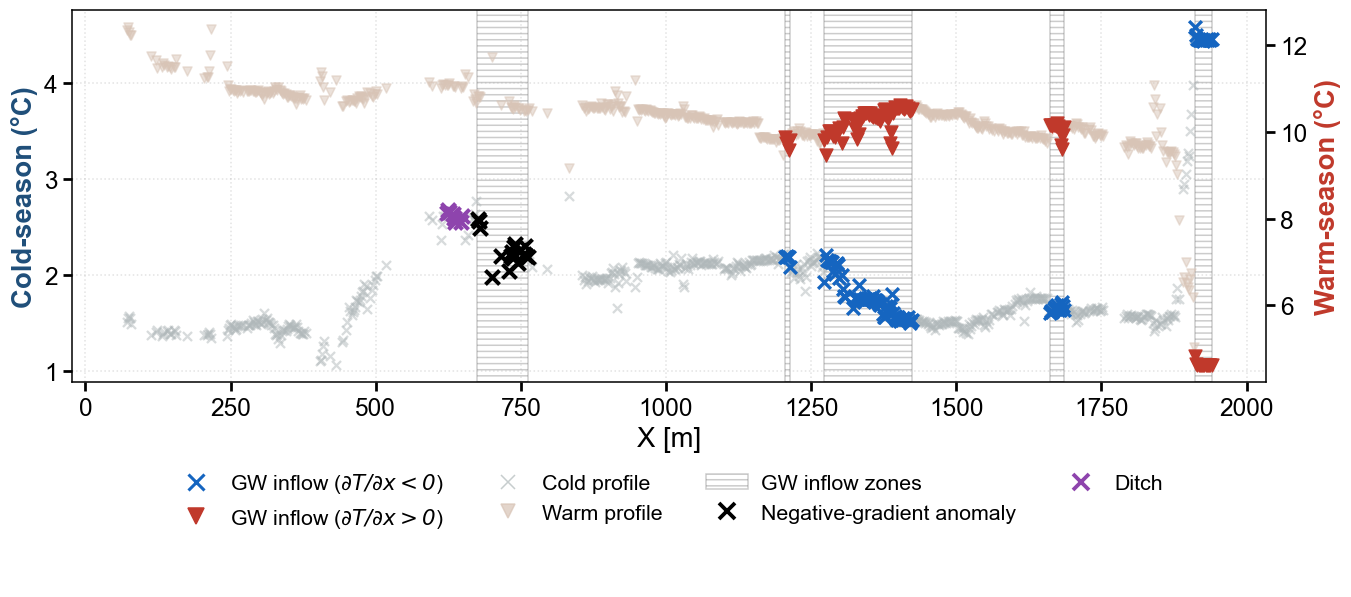

In [42]:

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# --- FIGURE ---
fig_gw = plt.figure(figsize=(14, 6.8))
gs_gw  = mpl.gridspec.GridSpec(2, 1, height_ratios=[5, 2.3], hspace=0.12)

ax_c   = fig_gw.add_subplot(gs_gw[0])
ax_w   = ax_c.twinx()
ax_lg  = fig_gw.add_subplot(gs_gw[1])
ax_lg.axis("off")

# --- GW HATCH (revision style: grey ---, hollow) ---
for xs_, xe_ in gw_hatch_segments:
    ax_c.axvspan(xs_, xe_,
                 facecolor="none",
                 edgecolor="grey",
                 hatch="---",
                 alpha=0.40,
                 zorder=1)

# --- CLASSIFICATION ---
cold_is_black = anom_mask.values
cold_is_blue  = (gw_mask == 1) & (~cold_is_black)
cold_is_purp  = purple_mask.values
cold_is_bg    = (~cold_is_blue) & (~cold_is_black) & (~cold_is_purp)

# --- COLD ---
ax_c.scatter(x[cold_is_bg], min_data.values[cold_is_bg],
             color="#b0b8ba", marker="x", s=35, alpha=0.5, zorder=2)

ax_c.scatter(x[cold_is_blue], min_data.values[cold_is_blue],
             color=COLORS["gw"], marker="x", s=70, linewidths=2.2, zorder=4)

ax_c.scatter(x[cold_is_black], min_data.values[cold_is_black],
             color=COLORS["anomaly"], marker="x", s=85, linewidths=2.6, zorder=5)

ax_c.scatter(x[cold_is_purp], min_data.values[cold_is_purp],
             color=COLORS["ditch"], marker="x", s=85, linewidths=2.6, zorder=5)

# --- WARM ---
warm_bg = gw_mask != 1

ax_w.scatter(x[warm_bg], max_data.values[warm_bg],
             color="#d8c4b6", marker="v", s=35, alpha=0.5, zorder=2)

ax_w.scatter(x[gw_mask == 1], max_data.values[gw_mask == 1],
             color=COLORS["warm"], marker="v", s=70, zorder=4)

# --- LABELS (BIG + BOLD) ---
ax_c.set_ylabel("Cold-season (°C)",
                fontsize=18, fontweight="bold", color=COLORS["cold"])

ax_w.set_ylabel("Warm-season (°C)",
                fontsize=18, fontweight="bold", color=COLORS["warm"])

ax_c.set_xlabel("X [m]",
                fontsize=18)

# --- TICKS  ---
ax_c.tick_params(axis="both", labelsize=16, width=1.8, length=6)
ax_w.tick_params(axis="y", labelsize=16, width=1.8, length=6)

# --- FULL PLOT FRAME (all sides)---
ax_c.spines["left"].set_visible(True)
ax_c.spines["bottom"].set_visible(True)
ax_c.spines["top"].set_visible(True)
ax_c.spines["right"].set_visible(False)
ax_w.spines["right"].set_visible(True)
ax_w.spines["left"].set_visible(False)
ax_w.spines["bottom"].set_visible(False)
ax_w.spines["top"].set_visible(False)
for _ax in (ax_c, ax_w):
    for _sp in _ax.spines.values():
        if _sp.get_visible():
            _sp.set_linewidth(1.0)

# --- GRID ---
ax_c.grid(True, linestyle=":", linewidth=1.0, alpha=0.35)



# --- LEGEND ---
legend_handles = [
    Line2D([], [], color=COLORS["gw"], marker="x", linestyle="",
           markersize=10, markeredgewidth=2),
    Line2D([], [], color=COLORS["warm"], marker="v", linestyle="",
           markersize=10),
    Line2D([], [], color="#b0b8ba", marker="x", linestyle="",
           markersize=9, alpha=0.7),
    Line2D([], [], color="#d8c4b6", marker="v", linestyle="",
           markersize=9, alpha=0.7),
    mpatches.Patch(facecolor="none", edgecolor="grey", hatch="---", alpha=0.40),
    Line2D([], [], color=COLORS["anomaly"], marker="x", linestyle="",
           markersize=11, markeredgewidth=2.5),
    Line2D([], [], color=COLORS["ditch"], marker="x", linestyle="",
           markersize=11, markeredgewidth=2.5),
]

legend_labels = [
    r"GW inflow ($\partial T/\partial x < 0$)",
    r"GW inflow ($\partial T/\partial x > 0$)",
    "Cold profile",
    "Warm profile",
    "GW inflow zones",
    "Negative-gradient anomaly",
    "Ditch",
]

ax_lg.legend(legend_handles, legend_labels,
             loc="center",
             ncol=4,
             fontsize=14,
             frameon=False,
             columnspacing=2.0,
             handletextpad=0.6)

plt.tight_layout()

import os

_out_article_dir = (
    r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk"
    r"\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025"
    r"\Final Final Revision plots with SW"
)

os.makedirs(_out_article_dir, exist_ok=True)

# PNG
_out_runoff_png = os.path.join(_out_article_dir, "GW.png")

plt.savefig(
    _out_runoff_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved PNG:", _out_runoff_png)

#pdf
_out_runoff_pdf = os.path.join(_out_article_dir, "GW.pdf")

plt.savefig(
    _out_runoff_pdf,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved PDF:", _out_runoff_pdf)

# SVG
_out_runoff_svg = os.path.join(_out_article_dir, "GW.svg")

plt.savefig(
    _out_runoff_svg,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved SVG:", _out_runoff_svg)

plt.show()


[TIME_PERIOD = 'night']  →  night (22:00–06:00) + snow>0.0, Q>0.2
  envelope timesteps : 19179
  melt-mean timesteps: 732
Method G — final (Method 3 only)
  baseline    : upstream-only, w=40, GW masked above x = 1800 m
  cooling thr : 0.03 °C  (was 0.06)
  curvature   : d²T/dx² > 0  (unchanged)
  SW zones    : 5
  SW points   : 96

    Zone 1:    353 –    473 m  (width 120 m)
    Zone 2:    876 –    899 m  (width 22 m)
    Zone 3:   1177 –   1185 m  (width 8 m)
    Zone 4:   1447 –   1497 m  (width 51 m)
    Zone 5:   1621 –   1656 m  (width 34 m)
Saved PNG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\GW_SW_method_G_main_profile.png
Saved PDF: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\GW_SW_method_G_main_profile.pdf
Saved SVG: C:\Users\pparvizi24\OneDrive - University

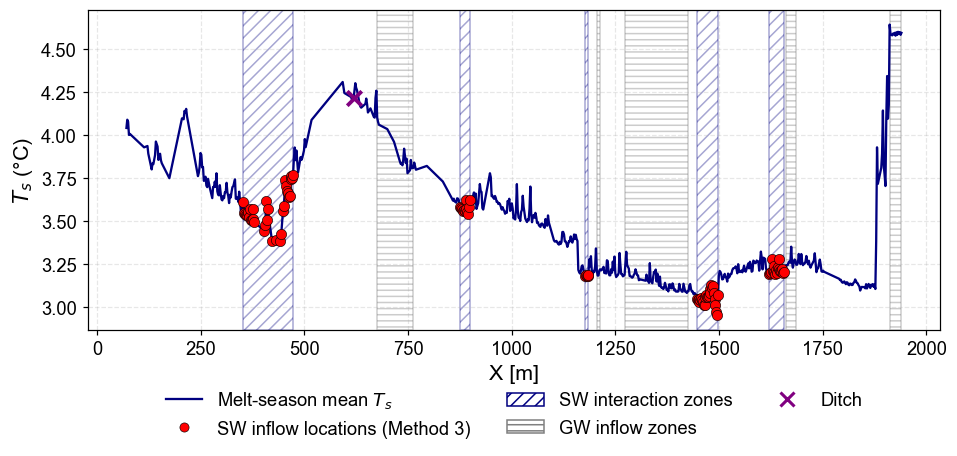

Saved PNG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\SW.png
Saved SVG: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\SW.svg


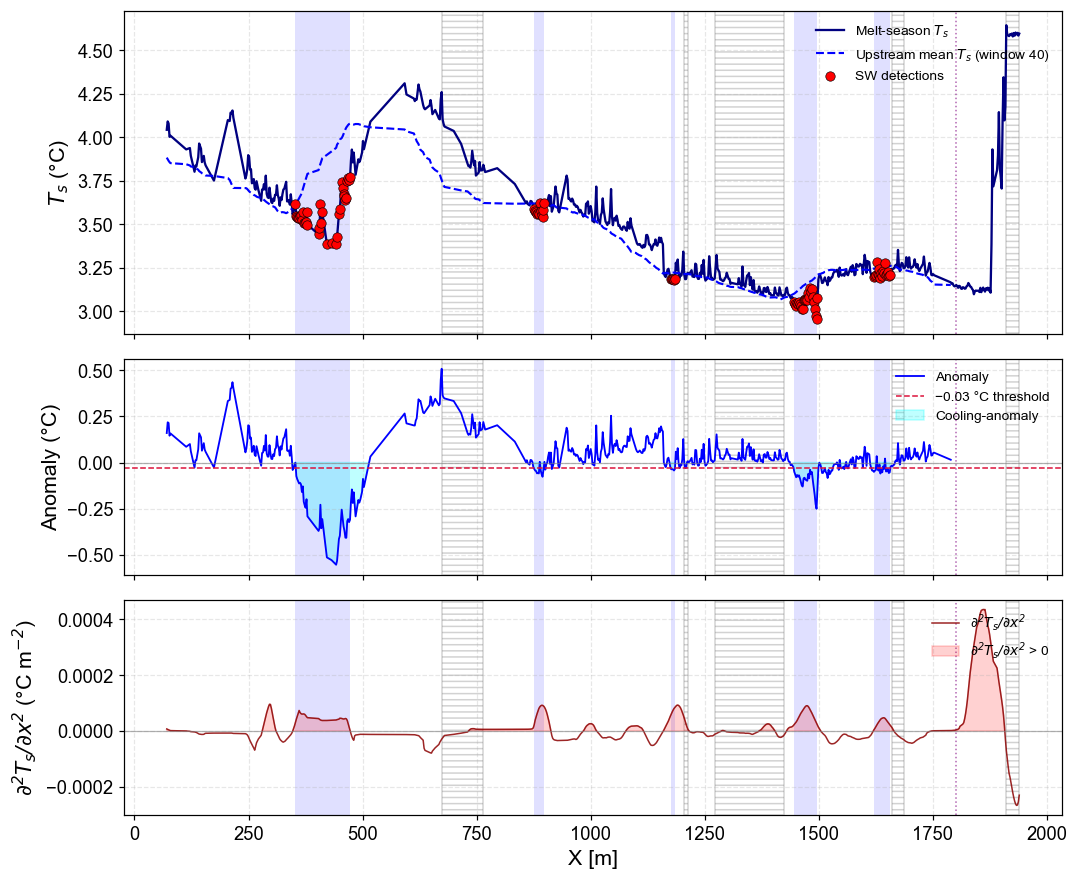

In [43]:

# SW method
TIME_PERIOD = "night"    # "night" | "day" | "all"
                         #   night : 22:00 – 06:00
                         #   day   : 06:00 – 22:00
                         #   all   : no hour filter
APPLY_MELT_FILTER = True # snow > 0 and Q > 0.2 (melt-season only)

window_m3    = 40         # rolling-window length (points)
d2_window_m3 = 20         # window for second derivative
cool_thr_m3  = 0.03        # cooling threshold (°C)
gw_mask_x_m3 = 1800.0     # x above which GW-spring is masked from baseline

snow_thresh = 0.0
Q_thresh    = 0.2

# =========================================================================
# 1. IMPORTS & RC
# =========================================================================
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore", message="All-NaN slice encountered")
warnings.filterwarnings("ignore", message=".*tight_layout.*")

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "Arial", "font.style": "normal", "font.size": 13,
    "axes.labelsize": 14, "axes.titlesize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.dpi": 110, "savefig.dpi": 600,
})

# =========================================================================
# 2. FILE PATHS
# =========================================================================
file        = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\DTS\pallas_dts_data_f_6.nc"
runoff_file = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\Forcing\30 min interval Discharge.New csv file.csv"
snow_file   = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\DTS_LJO_data\Forcing\Snow depth kittila.csv"
gw_csv      = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\Bachup\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\DTS_analysis_LJO\GW_inflow_locations_slope.csv"

# =========================================================================
# 3. HELPERS
# =========================================================================
def merge_intervals(intervals, tol=0.0):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda t: t[0])
    merged = [list(intervals[0])]
    for s, e in intervals[1:]:
        if s <= merged[-1][1] + tol:
            merged[-1][1] = max(merged[-1][1], e)
        else:
            merged.append([s, e])
    return [(a, b) for a, b in merged]

def extract_segments(xvals, mask01):
    segments = []
    in_seg = False
    for i in range(len(xvals)):
        if mask01[i] == 1 and not in_seg:
            start = xvals[i]; in_seg = True
        if in_seg and (mask01[i] == 0 or i == len(xvals) - 1):
            end = xvals[i - 1] if mask01[i] == 0 else xvals[i]
            segments.append((start, end)); in_seg = False
    return segments

def rolling_slope(T, window):
    T_roll = T.rolling(x=window, center=True).construct("window")
    x_win  = T["x"].rolling(x=window, center=True).construct("window")
    x_cent = x_win - T["x"].values[:, None]
    return (
        (x_cent * T_roll).mean("window")
        - x_cent.mean("window") * T_roll.mean("window")
    ) / (
        (x_cent**2).mean("window") - (x_cent.mean("window"))**2
    )

def upstream_baseline_m3(da, window):
    """Flow is 2000 m -> 0 m, so 'upstream' = larger x.
    Reverse, trailing rolling mean with shift(1) (exclude self), reverse back."""
    s_rev = pd.Series(da.values[::-1])
    base_rev = s_rev.shift(1).rolling(window=window, min_periods=5).mean()
    return xr.DataArray(base_rev.values[::-1],
                        coords={"x": da["x"]}, dims="x")

# =========================================================================
# 4. READ DATA
# =========================================================================
data = xr.open_dataset(file)

runoff_df = pd.read_csv(runoff_file)
runoff_df["time"] = pd.to_datetime(runoff_df["datetime"])
runoff_df = runoff_df.set_index("time").sort_index()
Q = pd.to_numeric(runoff_df["Discharge"], errors="coerce").dropna()
Q_xr = xr.DataArray(Q.values, coords={"time": Q.index}, dims="time")

snow_df = pd.read_csv(snow_file, low_memory=False)
snow_df["time"] = pd.to_datetime(
    snow_df["Year"].astype(str) + "-" +
    snow_df["Month"].astype(str).str.zfill(2) + "-" +
    snow_df["Day"].astype(str).str.zfill(2) + " " +
    snow_df["Time [Local time]"].astype(str),
    errors="coerce",
)
snow_df = snow_df.dropna(subset=["time"]).set_index("time").sort_index()
snow_col = "Snow depth [cm]"
snow_df[snow_col] = pd.to_numeric(snow_df[snow_col], errors="coerce")
snow_df.loc[snow_df[snow_col] < 0, snow_col] = 0.0
snow_df = snow_df.groupby(snow_df.index).mean(numeric_only=True)
snow_xr = xr.DataArray((snow_df[snow_col] / 100.0).values,
                       coords={"time": snow_df.index}, dims="time")

dts_time = data["time"]
Q_xr    = Q_xr.interp(time=dts_time)
snow_xr = snow_xr.interp(time=dts_time)

# =========================================================================
# 5. TIME-PERIOD MASK 
# =========================================================================
tp = TIME_PERIOD.lower().strip()
if tp == "night":
    period_mask = (dts_time.dt.hour >= 22) | (dts_time.dt.hour < 6)
    period_label = "night (22:00–06:00)"
elif tp == "day":
    period_mask = (dts_time.dt.hour >= 6) & (dts_time.dt.hour < 22)
    period_label = "day (06:00–22:00)"
elif tp == "all":
    period_mask = xr.ones_like(dts_time, dtype=bool)
    period_label = "all hours"
else:
    raise ValueError("TIME_PERIOD must be 'night', 'day', or 'all'")

if APPLY_MELT_FILTER:
    melt_mask_tp = period_mask & (snow_xr > snow_thresh) & (Q_xr > Q_thresh)
    filt_label = f"{period_label} + snow>{snow_thresh}, Q>{Q_thresh}"
else:
    melt_mask_tp = period_mask
    filt_label = period_label

data_period      = data.sel(time=period_mask)      # for seasonal envelopes
data_melt_period = data.sel(time=melt_mask_tp)     # for the melt mean

print(f"[TIME_PERIOD = '{TIME_PERIOD}']  →  {filt_label}")
print(f"  envelope timesteps : {int(period_mask.sum())}")
print(f"  melt-mean timesteps: {int(melt_mask_tp.sum())}")

# =========================================================================
# 6. BUILD PROFILES 
# =========================================================================
min_data = data_period["T"].quantile(0.25, dim="time").dropna(dim="x")
max_data = data_period["T"].quantile(0.75, dim="time").dropna(dim="x")

melt_mean = data_melt_period["T"].mean(dim="time").dropna(dim="x")
x         = melt_mean["x"]

# Derivatives from the SAME melt_mean
melt_deriv_m3 = rolling_slope(melt_mean, window_m3)
d2_mg         = rolling_slope(melt_deriv_m3, d2_window_m3)
pos_curv_mg   = (d2_mg > 0)

# =========================================================================
# 7. GW HATCH SEGMENTS
# =========================================================================
csv_df = pd.read_csv(gw_csv)
csv_segments = [(float(a), float(b))
                for a, b in zip(csv_df["x_start_m"].values, csv_df["x_end_m"].values)]
csv_segments.append((675.0, 763.0))   # anomaly zone
gw_hatch_segments = merge_intervals(csv_segments, tol=0.0)

# =========================================================================
# 8. UPSTREAM-ONLY BASELINE (with GW spring masked)
# =========================================================================
melt_for_base_m3 = melt_mean.where(x <= gw_mask_x_m3)
T_base_m3        = upstream_baseline_m3(melt_for_base_m3, window_m3)
anom_m3          = melt_mean - T_base_m3
cooling_m3       = (anom_m3 < -cool_thr_m3)

# =========================================================================
# 9. DETECTION (positive curvature & cooling anomaly)
# =========================================================================
sw_m3 = xr.where(pos_curv_mg & cooling_m3, 1, np.nan)

# spatial coherence (>=3 of 5 neighbours)
sw_m3 = xr.where(
    sw_m3.rolling(x=5, center=True, min_periods=1).sum() > 2,
    1, np.nan
)
sw_m3 = xr.where(x > 1900, np.nan, sw_m3)

sw_m3_mask = sw_m3.fillna(0).astype(int).values

sw_m3_segs = merge_intervals(extract_segments(x.values, sw_m3_mask),
                             tol=15.0)
for s_, e_ in sw_m3_segs:
    sw_m3_mask[(x.values >= s_) & (x.values <= e_)] = 1

# --- 3. Print summary ---------------------------------------------------
print("Method G — final (Method 3 only)")
print(f"  baseline    : upstream-only, w={window_m3}, "
      f"GW masked above x = {gw_mask_x_m3:.0f} m")
print(f"  cooling thr : {cool_thr_m3} °C  (was 0.06)")
print(f"  curvature   : d²T/dx² > 0  (unchanged)")
print(f"  SW zones    : {len(sw_m3_segs)}")
print(f"  SW points   : {int(sw_m3_mask.sum())}")
print()
for i, (s_, e_) in enumerate(sw_m3_segs):
    print(f"    Zone {i+1}: {s_:6.0f} – {e_:6.0f} m  "
          f"(width {e_-s_:.0f} m)")

# --- 4. Main result figure ---------------------------------------------
fig_m3 = plt.figure(figsize=(10, 5))
gs_m3  = mpl.gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.12)

axm3   = fig_m3.add_subplot(gs_m3[0])
ax_lg3 = fig_m3.add_subplot(gs_m3[1])
ax_lg3.axis("off")

for xs_, xe_ in gw_hatch_segments:
    axm3.axvspan(xs_, xe_, facecolor="none", edgecolor="grey",
                 hatch="---", alpha=0.40)

for xs_, xe_ in sw_m3_segs:
    axm3.axvspan(xs_, xe_, facecolor="none", edgecolor="navy",
                 hatch="///", alpha=0.35)

axm3.plot(x, melt_mean, color="navy", lw=1.5)
axm3.scatter(x[sw_m3_mask == 1], melt_mean.values[sw_m3_mask == 1],
             color="red", edgecolor="black", linewidth=0.4, s=45, zorder=3)

ditch_mid_m3 = 620
ditch_idx_m3 = np.argmin(np.abs(x.values - ditch_mid_m3))
axm3.scatter(x.values[ditch_idx_m3], melt_mean.values[ditch_idx_m3],
             color="purple", marker="x", s=90, linewidths=2.5, zorder=5)

axm3.set_ylabel(r"$T_{\mathrm{s}}$ (°C)")
axm3.set_xlabel("X [m]")
axm3.grid(True, linestyle="--", alpha=0.3)


ax_lg3.legend(
    [
        plt.Line2D([], [], color="navy", linewidth=1.5),
        plt.Line2D([], [], color="red", marker="o", linestyle="",
                   markeredgecolor="black", markeredgewidth=0.4),
        mpl.patches.Patch(facecolor="none", hatch="///", edgecolor="navy"),
        mpl.patches.Patch(facecolor="none", edgecolor="grey", hatch="---"),
        plt.Line2D([], [], color="purple", marker="x", linestyle="",
                   markersize=9, markeredgewidth=2),
    ],
    [
        r"Melt-season mean $T_{\mathrm{s}}$",
        "SW inflow locations (Method 3)",
        "SW interaction zones",
        "GW inflow zones",
        "Ditch",
    ],
    loc="center", bbox_to_anchor=(0.5, 0.25), ncol=3, frameon=False
)

plt.tight_layout()

import os

_out_article_dir = (
    r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk"
    r"\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025"
    r"\Final Final Revision plots with SW"
)

os.makedirs(_out_article_dir, exist_ok=True)

# PNG
_out_sw_main_png = os.path.join(
    _out_article_dir,
    "GW_SW_method_G_main_profile.png"
)

fig_m3.savefig(
    _out_sw_main_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved PNG:", _out_sw_main_png)

#PDF
_out_sw_main_pdf = os.path.join(
    _out_article_dir,
    "GW_SW_method_G_main_profile.pdf"
)

fig_m3.savefig(
    _out_sw_main_pdf,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved PDF:", _out_sw_main_pdf)

# SVG
_out_sw_main_svg = os.path.join(
    _out_article_dir,
    "GW_SW_method_G_main_profile.svg"
)

fig_m3.savefig(
    _out_sw_main_svg,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved SVG:", _out_sw_main_svg)

plt.show()

# --- 5. Diagnostic 3-panel figure (Ts+baseline / anomaly / curvature) --
fig_m3d, ax_m3d = plt.subplots(3, 1, figsize=(11, 9.5), sharex=True,
                               gridspec_kw={"hspace": 0.10,
                                            "height_ratios": [3, 2, 2]})

for ax in ax_m3d:
    for xs_, xe_ in gw_hatch_segments:
        ax.axvspan(xs_, xe_, facecolor="none", edgecolor="grey",
                   hatch="---", alpha=0.35, zorder=0)
    for xs_, xe_ in sw_m3_segs:
        ax.axvspan(xs_, xe_, facecolor="blue", alpha=0.12, zorder=0)
    ax.axvline(gw_mask_x_m3, color="purple", ls=":", lw=1.0, alpha=0.6)

# (a) Ts + baseline + detections
ax = ax_m3d[0]
ax.plot(x, melt_mean, color="navy", lw=1.5,
        label=r"Melt-season $T_s$")
ax.plot(x, T_base_m3, color="blue", lw=1.4, ls="--",
        label=f"Upstream mean $T_s$ (window {window_m3})")
ax.scatter(x.values[sw_m3_mask == 1], melt_mean.values[sw_m3_mask == 1],
           color="red", edgecolor="black", linewidth=0.4,
           s=38, zorder=3, label="SW detections")
ax.set_ylabel(r"$T_s$ (°C)")
ax.grid(True, ls="--", alpha=0.3)
ax.legend(loc="upper right", frameon=False, fontsize=9)
#ax.set_title

# (b) cooling-anomaly criterion (threshold 0.03)
ax = ax_m3d[1]
a_vals_m3 = anom_m3.values
ax.plot(x, anom_m3, color="blue", lw=1.2, label="Anomaly")
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.axhline(-cool_thr_m3, color="crimson", ls="--", lw=1.0,
           label=f"−{cool_thr_m3} °C threshold")
ax.fill_between(x.values, 0, a_vals_m3,
                where=(a_vals_m3 < -cool_thr_m3),
                color="cyan", alpha=0.25, interpolate=True,
                label="Cooling-anomaly")
ax.set_ylabel("Anomaly (°C)")
ax.grid(True, ls="--", alpha=0.3)
ax.legend(loc="upper right", frameon=False, fontsize=9)

# (c) positive-curvature criterion
ax = ax_m3d[2]
ax.plot(x, d2_mg, color="darkred", lw=1.0, alpha=0.85,
        label=r"$\partial^2 T_s / \partial x^2$")
ax.axhline(0.0, color="grey", lw=0.8, alpha=0.6)
ax.fill_between(x.values, 0, d2_mg.values,
                where=(d2_mg.values > 0),
                color="red", alpha=0.18, interpolate=True,
                label="$\partial^2 T_s / \partial x^2$ > 0")
ax.set_xlabel("X [m]")
ax.set_ylabel(r"$\partial^2 T_s / \partial x^2$ (°C m$^{-2}$)")
ax.grid(True, ls="--", alpha=0.3)
ax.legend(loc="upper right", frameon=False, fontsize=9)

plt.tight_layout()

# PNG
_out_sw_diag_png = os.path.join(_out_article_dir, "SW.png")

fig_m3d.savefig(
    _out_sw_diag_png,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved PNG:", _out_sw_diag_png)

# SVG
_out_sw_diag_svg = os.path.join(_out_article_dir, "SW.svg")

fig_m3d.savefig(
    _out_sw_diag_svg,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)

print("Saved SVG:", _out_sw_diag_svg)

plt.show()

In [44]:
# =========================================================================
# Export GW & SW zones to CSV
#   - Ditch area (620–650 m) is kept identical in BOTH files
#   - Zones are merged so the ditch doesn't double-count if it overlaps
# =========================================================================
DITCH_RANGE = (620.0, 650.0)

# --- GW zones: hatch segments (CSV reversal + anomaly) + ditch -----------
gw_zones = merge_intervals(list(gw_hatch_segments) + [DITCH_RANGE], tol=0.0)

# --- SW zones: detected SW segments + ditch -------------------------------
sw_zones = merge_intervals(list(sw_m3_segs) + [DITCH_RANGE], tol=0.0)

# --- Build DataFrames ----------------------------------------------------
gw_df = pd.DataFrame(
    [(i + 1, s, e, e - s, "ditch" if (s, e) == DITCH_RANGE else "gw")
     for i, (s, e) in enumerate(gw_zones)],
    columns=["zone_id", "x_start_m", "x_end_m", "width_m", "type"],
)

sw_df = pd.DataFrame(
    [(i + 1, s, e, e - s, "ditch" if (s, e) == DITCH_RANGE else "sw")
     for i, (s, e) in enumerate(sw_zones)],
    columns=["zone_id", "x_start_m", "x_end_m", "width_m", "type"],
)

# --- Save ----------------------------------------------------------------
gw_out = Path("GW_zones.csv")
sw_out = Path("SW_zones.csv")
gw_df.to_csv(gw_out, index=False)
sw_df.to_csv(sw_out, index=False)

# --- Print ---------------------------------------------------------------
print(f"Ditch area kept identical in both files: "
      f"{DITCH_RANGE[0]:.0f}–{DITCH_RANGE[1]:.0f} m\n")

print(f"GW zones  ({len(gw_zones)})  ->  {gw_out}")
for _, r in gw_df.iterrows():
    print(f"  Zone {int(r.zone_id):>2}: {r.x_start_m:6.0f} – {r.x_end_m:6.0f} m  "
          f"(width {r.width_m:5.0f} m)  [{r.type}]")

print(f"\nSW zones  ({len(sw_zones)})  ->  {sw_out}")
for _, r in sw_df.iterrows():
    print(f"  Zone {int(r.zone_id):>2}: {r.x_start_m:6.0f} – {r.x_end_m:6.0f} m  "
          f"(width {r.width_m:5.0f} m)  [{r.type}]")


Ditch area kept identical in both files: 620–650 m

GW zones  (6)  ->  GW_zones.csv
  Zone  1:    620 –    650 m  (width    30 m)  [ditch]
  Zone  2:    675 –    763 m  (width    88 m)  [gw]
  Zone  3:   1205 –   1213 m  (width     8 m)  [gw]
  Zone  4:   1272 –   1424 m  (width   152 m)  [gw]
  Zone  5:   1662 –   1686 m  (width    24 m)  [gw]
  Zone  6:   1911 –   1940 m  (width    28 m)  [gw]

SW zones  (6)  ->  SW_zones.csv
  Zone  1:    353 –    473 m  (width   120 m)  [sw]
  Zone  2:    620 –    650 m  (width    30 m)  [ditch]
  Zone  3:    876 –    899 m  (width    22 m)  [sw]
  Zone  4:   1177 –   1185 m  (width     8 m)  [sw]
  Zone  5:   1447 –   1497 m  (width    51 m)  [sw]
  Zone  6:   1621 –   1656 m  (width    34 m)  [sw]
